# Análisis de resultados — corridas Monte Carlo

Este notebook lee los CSV generados por `experiments/run_batch.py` (uno por
corrida de `python experiments/run_batch.py`, guardados en `data/results/`)
y compara las dos configuraciones de salida que probamos: una salida
centrada vs. dos salidas en los extremos, para distintas cantidades de
agentes.

Cada fila del CSV es **un paso de una corrida particular** (no un resumen):
si corriste 60 combinaciones y cada una tardó en promedio ~70 pasos en
evacuar a todos, vas a tener miles de filas. Por eso el primer trabajo acá
es *resumir* antes de poder comparar nada.

In [1]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAIZ_PROYECTO = Path.cwd().parent
CARPETA_RESULTADOS = RAIZ_PROYECTO / "data" / "results"

csvs_disponibles = sorted(CARPETA_RESULTADOS.glob("batch_*.csv"))
print(f"{len(csvs_disponibles)} archivo(s) de resultados encontrados:")
for csv in csvs_disponibles:
    print(" -", csv.name)

# Toma el mas reciente. Si queres comparar corridas de distintos dias,
# cambia esta linea por pd.concat([pd.read_csv(c) for c in csvs_disponibles]).
df = pd.read_csv(csvs_disponibles[-1])
df.head()

1 archivo(s) de resultados encontrados:
 - batch_20260917_235359.csv


,RunId,iteration,Step,ancho,alto,muros,salidas,num_agentes,rng,evacuados,restantes
0,0,0,0.0,20,15,[],"[(19, 7)]",30,0,0,30
1,0,0,1.0,20,15,[],"[(19, 7)]",30,0,0,30
2,0,0,2.0,20,15,[],"[(19, 7)]",30,0,0,30
3,0,0,3.0,20,15,[],"[(19, 7)]",30,0,0,30
4,0,0,4.0,20,15,[],"[(19, 7)]",30,0,1,29


## Preparar los datos

La columna `salidas` viene del CSV como texto (por ejemplo `"[(19, 7)]"`),
porque `to_csv` convierte cualquier valor a su representación en texto.
`ast.literal_eval` la convierte de vuelta a una lista de Python real, y de
ahí sacamos algo mucho más útil para comparar: **cuántas salidas tenía esa
corrida**.

In [2]:
df["salidas"] = df["salidas"].apply(ast.literal_eval)
df["cantidad_de_salidas"] = df["salidas"].apply(len)

df[["RunId", "Step", "num_agentes", "cantidad_de_salidas", "evacuados", "restantes"]].head()

,RunId,Step,num_agentes,cantidad_de_salidas,evacuados,restantes
0,0,0.0,30,1,0,30
1,0,1.0,30,1,0,30
2,0,2.0,30,1,0,30
3,0,3.0,30,1,0,30
4,0,4.0,30,1,1,29


## Resumen por corrida

Cada `RunId` es una corrida completa (una combinación de parámetros + una
semilla). Nos quedamos con la **última fila de cada corrida** (el paso
final), que nos dice cuántos pasos tardó en evacuar a todos.

In [3]:
resumen_por_corrida = (
    df.sort_values("Step")
    .groupby("RunId")
    .tail(1)
    .loc[:, ["RunId", "cantidad_de_salidas", "num_agentes", "rng", "Step", "evacuados", "restantes"]]
    .rename(columns={"Step": "pasos_hasta_evacuar"})
    .reset_index(drop=True)
)

assert (resumen_por_corrida["restantes"] == 0).all(), (
    "Alguna corrida no evacuo a todos los agentes dentro del limite de pasos"
)

resumen_por_corrida.head()

,RunId,cantidad_de_salidas,num_agentes,rng,pasos_hasta_evacuar,evacuados,restantes
0,15,2,30,2,28.0,30,0
1,39,2,30,6,29.0,30,0
2,9,2,30,1,30.0,30,0
3,3,2,30,0,32.0,30,0
4,21,2,30,3,32.0,30,0


## Tabla comparativa: ¿cuánto tarda cada configuración?

Agrupamos por configuración de salida y cantidad de agentes, y calculamos
el promedio y el desvío estándar de los pasos hasta evacuar entre las
10 repeticiones (semillas) de cada combinación. El desvío estándar es la
parte "Monte Carlo": nos dice qué tan estable es ese resultado, no es solo
una corrida de suerte.

In [4]:
tabla_comparativa = (
    resumen_por_corrida.groupby(["cantidad_de_salidas", "num_agentes"])["pasos_hasta_evacuar"]
    .agg(promedio="mean", desvio="std", corridas="count")
    .round(1)
)
tabla_comparativa

promedio  desvio  corridas
cantidad_de_salidas num_agentes                            
1                   30               48.9     4.4        10
                    60               87.8     3.3        10
                    90              128.3     4.3        10
2                   30               32.4     3.0        10
                    60               54.9     4.2        10
                    90               76.4     3.0        10

## Gráfico 1: pasos hasta evacuar por configuración

Barras agrupadas por cantidad de agentes, comparando 1 vs 2 salidas. Las
líneas de error muestran el desvío estándar de las 10 repeticiones.

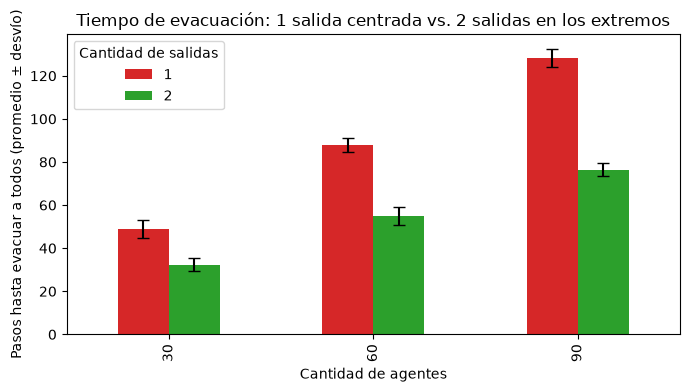

In [5]:
pivot_promedio = tabla_comparativa["promedio"].unstack("cantidad_de_salidas")
pivot_desvio = tabla_comparativa["desvio"].unstack("cantidad_de_salidas")

ax = pivot_promedio.plot(
    kind="bar",
    yerr=pivot_desvio,
    capsize=4,
    figsize=(7, 4),
    color=["#d62728", "#2ca02c"],
)
ax.set_xlabel("Cantidad de agentes")
ax.set_ylabel("Pasos hasta evacuar a todos (promedio ± desvío)")
ax.set_title("Tiempo de evacuación: 1 salida centrada vs. 2 salidas en los extremos")
ax.legend(title="Cantidad de salidas")
plt.tight_layout()
plt.show()

## Gráfico 2: curva de evacuación en el tiempo

Para esto no alcanza con el resumen final: queremos ver, paso a paso,
cuántos agentes ya evacuaron. El detalle importante es que **las 10
corridas de cada configuración terminan en pasos distintos** (una config
tarda más que otra), así que si promediamos directamente por `Step`, el
promedio de los últimos pasos queda calculado solo con las corridas que
todavía no habían terminado — un sesgo hacia las corridas más lentas.

La solución es "completar" cada corrida ya terminada repitiendo su último
valor (una vez que evacuaron todos, siguen evacuados) hasta el paso máximo
observado, y recién ahí promediar.

In [6]:
paso_maximo = int(df["Step"].max())


def completar_curva(grupo):
    grupo = grupo.set_index("Step").reindex(range(paso_maximo + 1))
    grupo["evacuados"] = grupo["evacuados"].ffill()
    columnas_fijas = ["cantidad_de_salidas", "num_agentes"]
    grupo[columnas_fijas] = grupo[columnas_fijas].ffill().bfill()
    return grupo


curvas_completas = (
    df.groupby("RunId", group_keys=True)
    .apply(completar_curva, include_groups=False)
    .reset_index()
)

curva_promedio = (
    curvas_completas.groupby(["cantidad_de_salidas", "num_agentes", "Step"])["evacuados"]
    .mean()
    .reset_index()
)
curva_promedio.head()

,cantidad_de_salidas,num_agentes,Step,evacuados
0,1.0,30.0,0,0.0
1,1.0,30.0,1,0.0
2,1.0,30.0,2,0.1
3,1.0,30.0,3,0.7
4,1.0,30.0,4,1.0


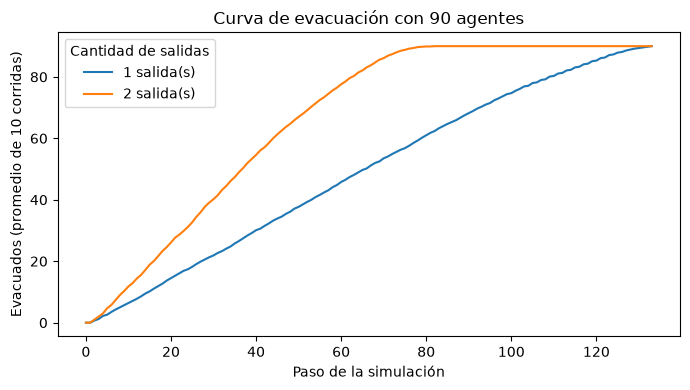

In [7]:
agentes_a_graficar = 90

fig, ax = plt.subplots(figsize=(7, 4))
for cantidad_salidas, grupo in curva_promedio[
    curva_promedio["num_agentes"] == agentes_a_graficar
].groupby("cantidad_de_salidas"):
    ax.plot(grupo["Step"], grupo["evacuados"], label=f"{int(cantidad_salidas)} salida(s)")

ax.set_xlabel("Paso de la simulación")
ax.set_ylabel("Evacuados (promedio de 10 corridas)")
ax.set_title(f"Curva de evacuación con {agentes_a_graficar} agentes")
ax.legend(title="Cantidad de salidas")
plt.tight_layout()
plt.show()

## Conclusión

Con este escenario (cuarto de 20x15 sin obstáculos), agregar una segunda
salida en el extremo opuesto reduce el tiempo de evacuación de forma
consistente en las tres cantidades de agentes probadas, con una variancia
entre repeticiones baja en comparación con la diferencia entre
configuraciones — es una diferencia real, no ruido de la simulación.

Próximos pasos naturales para el TP: repetir esta misma comparación
agregando muros/obstáculos internos (para ver si aparecen cuellos de
botella tipo "arqueo", el fenómeno de Helbing et al. 2000 que motivó este
proyecto), y probar más configuraciones de salida (3 salidas, salidas de
distinto ancho, etc.).